In [1]:
from google.colab import files
uploaded = files.upload()

Saving events_raw.csv to events_raw.csv
Saving users_meta.csv to users_meta.csv


In [2]:
import pandas as pd

events = pd.read_csv("events_raw.csv", parse_dates=["time"])
users = pd.read_csv("users_meta.csv")

events.head()

,user_id,event_type,time,prop_persona,prop_genre,prop_song_id,prop_plan
0,user_bae2d599,sign_up,2026-04-01 00:12:49,convert,NaN,NaN,NaN
1,user_a4106367,search_song,2026-04-01 00:49:16,NaN,jazz,NaN,NaN
2,user_ff4a7825,play_song,2026-04-01 02:08:00,NaN,hiphop,song_0145,NaN
3,user_fa932d29,sign_up,2026-04-01 02:28:27,churn,NaN,NaN,NaN
4,user_ff4a7825,complete_song,2026-04-01 03:00:40,NaN,NaN,song_0145,NaN


In [3]:
print(events.shape)
print(events.columns.tolist())
print(events["event_type"].value_counts())

(241956, 7)
['user_id', 'event_type', 'time', 'prop_persona', 'prop_genre', 'prop_song_id', 'prop_plan']
event_type
search_song            71694
play_song              71694
complete_song          57404
skip_song              14290
like_song              11689
open_app                8345
add_to_playlist         5783
sign_up                  800
subscribe_premium        233
cancel_subscription       24
Name: count, dtype: int64


In [4]:
signup = events[events.event_type == "sign_up"][["user_id", "time"]]
signup = signup.rename(columns={"time": "signup_time"})
signup.head()

,user_id,signup_time
0,user_bae2d599,2026-04-01 00:12:49
3,user_fa932d29,2026-04-01 02:28:27
9,user_68e50e38,2026-04-01 05:51:34
16,user_bd7db9a8,2026-04-01 08:25:51
18,user_07b85eca,2026-04-01 09:03:26


In [5]:
events = events.merge(signup, on="user_id")
events["days_since_signup"] = (events["time"] - events["signup_time"]).dt.days
events[["user_id", "event_type", "time", "days_since_signup"]].head(10)

,user_id,event_type,time,days_since_signup
0,user_bae2d599,sign_up,2026-04-01 00:12:49,0
1,user_a4106367,search_song,2026-04-01 00:49:16,-1
2,user_ff4a7825,play_song,2026-04-01 02:08:00,-1
3,user_fa932d29,sign_up,2026-04-01 02:28:27,0
4,user_ff4a7825,complete_song,2026-04-01 03:00:40,-1
5,user_a4106367,play_song,2026-04-01 03:16:34,-1
6,user_a4106367,complete_song,2026-04-01 03:21:59,-1
7,user_ff4a7825,play_song,2026-04-01 04:08:41,-1
8,user_bae2d599,like_song,2026-04-01 05:07:51,0
9,user_68e50e38,sign_up,2026-04-01 05:51:34,0


In [6]:
retention = (
    events[events.event_type == "open_app"]
    .groupby("days_since_signup")["user_id"]
    .nunique()
)
retention.head(15)

,user_id
days_since_signup,
-1,199
0,387
1,362
2,318
3,269
4,258
5,268
6,261
7,257


In [8]:
events["days_since_signup"] = events["days_since_signup"].clip(lower=0)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53584 (\N{HANGUL SYLLABLE TEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

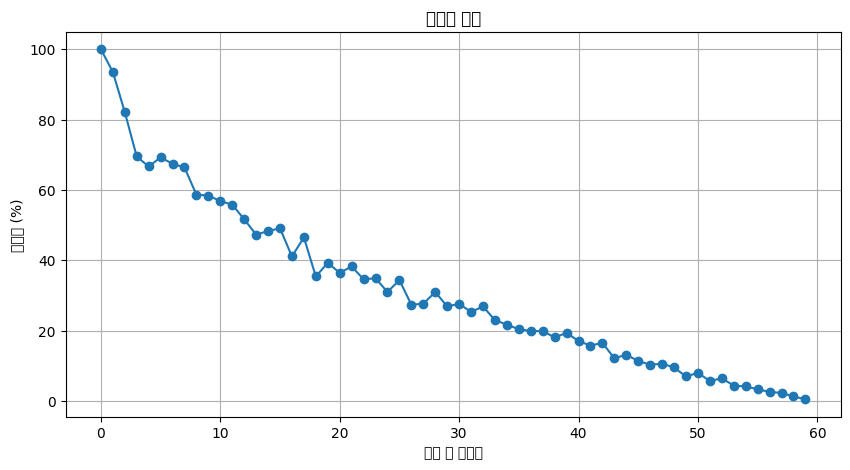

In [9]:
import matplotlib.pyplot as plt

retention_pct = retention / retention.iloc[1] * 100  # Day 0 인원 대비 비율(%)
retention_pct = retention_pct[retention_pct.index >= 0]

plt.figure(figsize=(10, 5))
plt.plot(retention_pct.index, retention_pct.values, marker='o')
plt.xlabel("가입 후 경과일")
plt.ylabel("리텐션 (%)")
plt.title("리텐션 커브")
plt.grid(True)
plt.show()

In [10]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm

fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

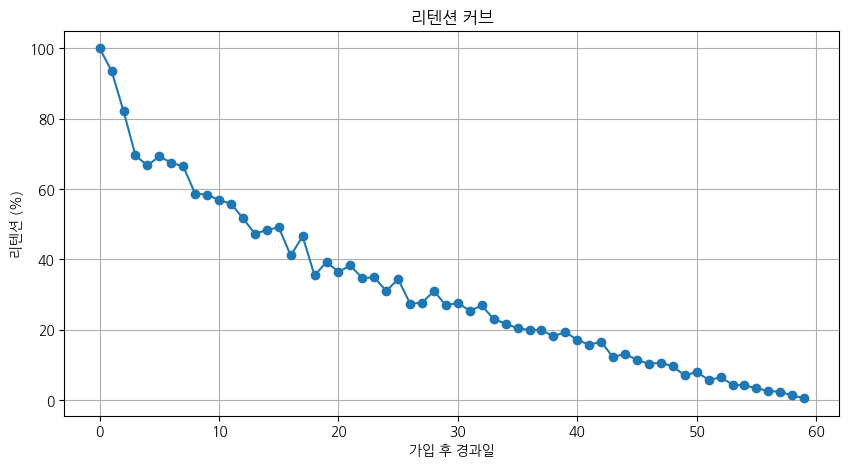

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(retention_pct.index, retention_pct.values, marker='o')
plt.xlabel("가입 후 경과일")
plt.ylabel("리텐션 (%)")
plt.title("리텐션 커브")
plt.grid(True)
plt.show()

In [12]:
funnel_steps = ["sign_up", "open_app", "play_song", "subscribe_premium"]

funnel_counts = []
for step in funnel_steps:
    n_users = events[events.event_type == step]["user_id"].nunique()
    funnel_counts.append(n_users)

funnel_df = pd.DataFrame({
    "단계": funnel_steps,
    "유저수": funnel_counts
})
funnel_df["전환율(%)"] = (funnel_df["유저수"] / funnel_df["유저수"].iloc[0] * 100).round(1)
funnel_df["단계별 전환율(%)"] = (funnel_df["유저수"] / funnel_df["유저수"].shift(1) * 100).round(1)

funnel_df

,단계,유저수,전환율(%),단계별 전환율(%)
0,sign_up,800,100.0,NaN
1,open_app,791,98.9,98.9
2,play_song,791,98.9,100.0
3,subscribe_premium,222,27.8,28.1


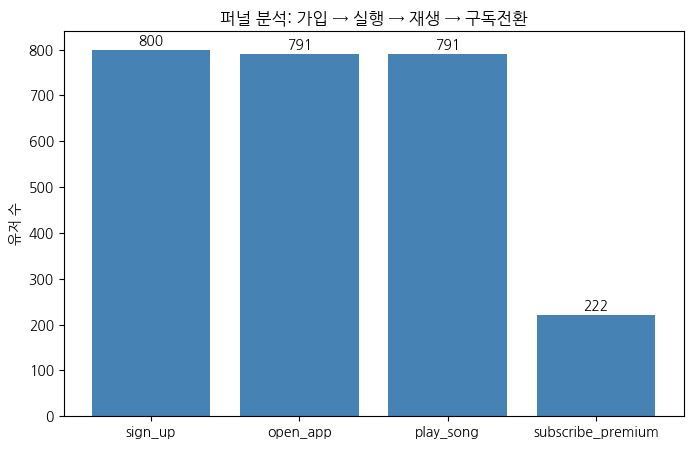

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(funnel_df["단계"], funnel_df["유저수"], color="steelblue")
for i, v in enumerate(funnel_df["유저수"]):
    plt.text(i, v + 10, str(v), ha="center")
plt.ylabel("유저 수")
plt.title("퍼널 분석: 가입 → 실행 → 재생 → 구독전환")
plt.show()

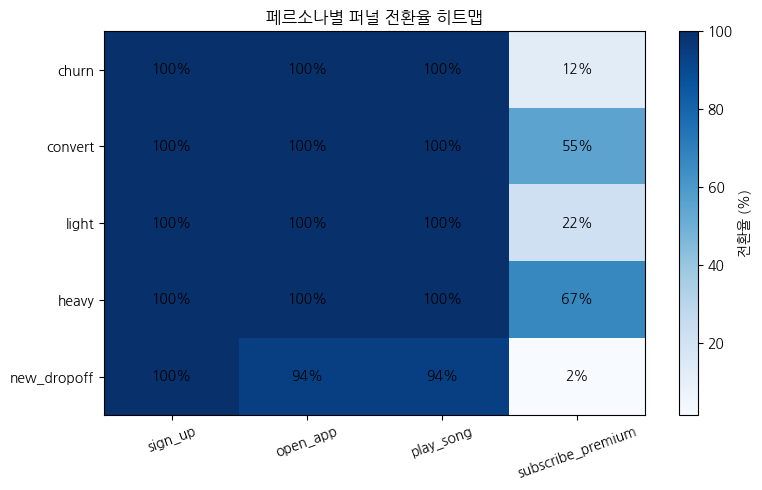

In [14]:
events_p = events.merge(users[["user_id", "persona"]], on="user_id")

funnel_matrix = pd.DataFrame(index=users["persona"].unique(), columns=funnel_steps)

for persona in funnel_matrix.index:
    persona_users = events_p[events_p.persona == persona]
    base = persona_users[persona_users.event_type == "sign_up"]["user_id"].nunique()
    for step in funnel_steps:
        n = persona_users[persona_users.event_type == step]["user_id"].nunique()
        funnel_matrix.loc[persona, step] = round(n / base * 100, 1) if base > 0 else 0

funnel_matrix = funnel_matrix.astype(float)

plt.figure(figsize=(8, 5))
plt.imshow(funnel_matrix, cmap="Blues", aspect="auto")
plt.colorbar(label="전환율 (%)")
plt.xticks(range(len(funnel_steps)), funnel_steps, rotation=20)
plt.yticks(range(len(funnel_matrix.index)), funnel_matrix.index)
for i in range(len(funnel_matrix.index)):
    for j in range(len(funnel_steps)):
        plt.text(j, i, f"{funnel_matrix.iloc[i,j]:.0f}%", ha="center", va="center")
plt.title("페르소나별 퍼널 전환율 히트맵")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1361/598715770.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


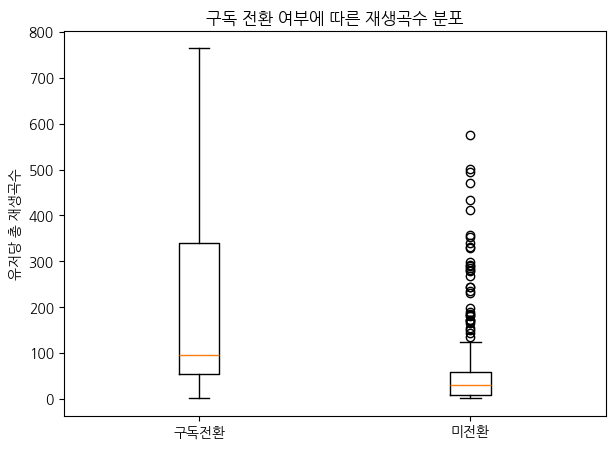

In [15]:
play_counts = events[events.event_type == "play_song"].groupby("user_id").size().rename("총재생곡수")

subscribed_users = events[events.event_type == "subscribe_premium"]["user_id"].unique()
play_df = play_counts.reset_index()
play_df["구독여부"] = play_df["user_id"].isin(subscribed_users).map({True: "구독전환", False: "미전환"})

plt.figure(figsize=(7, 5))
plt.boxplot(
    [play_df[play_df["구독여부"]=="구독전환"]["총재생곡수"],
     play_df[play_df["구독여부"]=="미전환"]["총재생곡수"]],
    labels=["구독전환", "미전환"]
)
plt.ylabel("유저당 총 재생곡수")
plt.title("구독 전환 여부에 따른 재생곡수 분포")
plt.show()

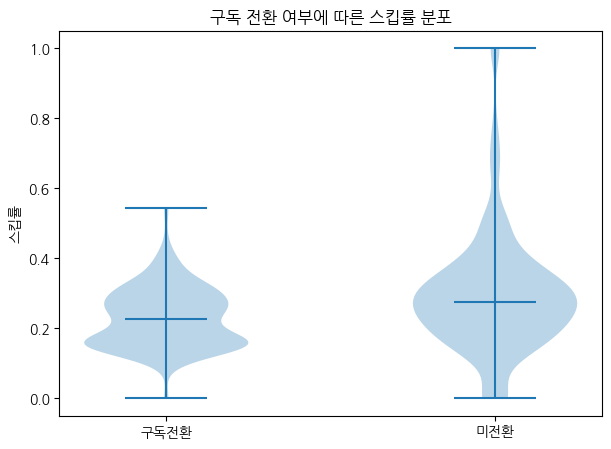

In [17]:
skip_counts = events[events.event_type == "skip_song"].groupby("user_id").size()
total_plays = events[events.event_type == "play_song"].groupby("user_id").size()
skip_rate = (skip_counts / total_plays).fillna(0).rename("스킵률").reset_index()
skip_rate.columns = ["user_id", "스킵률"]
skip_rate["구독여부"] = skip_rate["user_id"].isin(subscribed_users).map({True: "구독전환", False: "미전환"})

plt.figure(figsize=(7, 5))
plt.violinplot(
    [skip_rate[skip_rate["구독여부"]=="구독전환"]["스킵률"].dropna(),
     skip_rate[skip_rate["구독여부"]=="미전환"]["스킵률"].dropna()],
    showmedians=True
)
plt.xticks([1, 2], ["구독전환", "미전환"])
plt.ylabel("스킵률")
plt.title("구독 전환 여부에 따른 스킵률 분포")
plt.show()


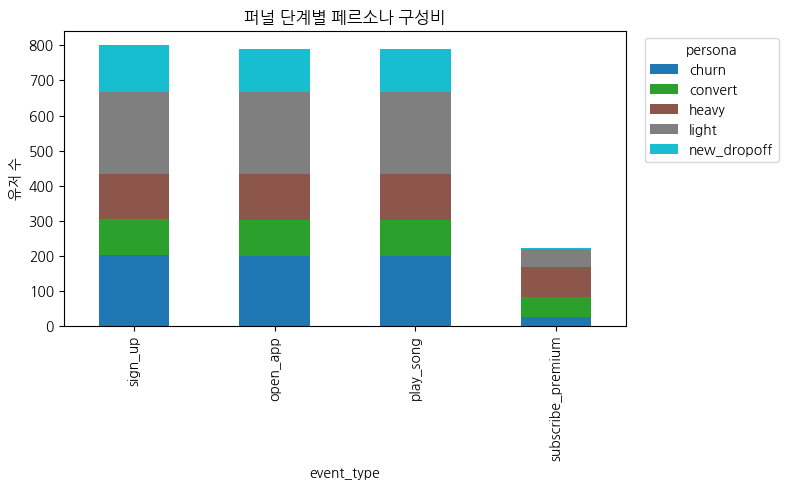

In [18]:
persona_step = events_p[events_p.event_type.isin(funnel_steps)].groupby(["event_type","persona"])["user_id"].nunique().unstack(fill_value=0)
persona_step = persona_step.loc[funnel_steps]

persona_step.plot(kind="bar", stacked=True, figsize=(8,5), colormap="tab10")
plt.ylabel("유저 수")
plt.title("퍼널 단계별 페르소나 구성비")
plt.legend(title="persona", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()